In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.5)

In [2]:
hard    = pd.read_csv('figures/pareto_hard_results.csv')
exploit = pd.read_csv('figures/pareto_exploit_results.csv')
rag     = pd.read_csv('figures/pareto_rag_results.csv')

print(f"hard protocols:    {hard['protocol'].unique().tolist()}")
print(f"exploit protocols: {exploit['protocol'].unique().tolist()}")
print(f"rag protocols:     {rag['protocol'].unique().tolist()}")

hard protocols:    ['blue_defer', 'blue_edit', 'resample', 'trusted_monitoring', 'upfront_auditing', 'trusted_policy']
exploit protocols: ['blue_defer', 'blue_edit', 'resample', 'trusted_monitoring', 'upfront_auditing', 'trusted_policy']
rag protocols:     ['blue_defer', 'blue_edit', 'resample', 'trusted_monitoring', 'upfront_auditing', 'trusted_policy']


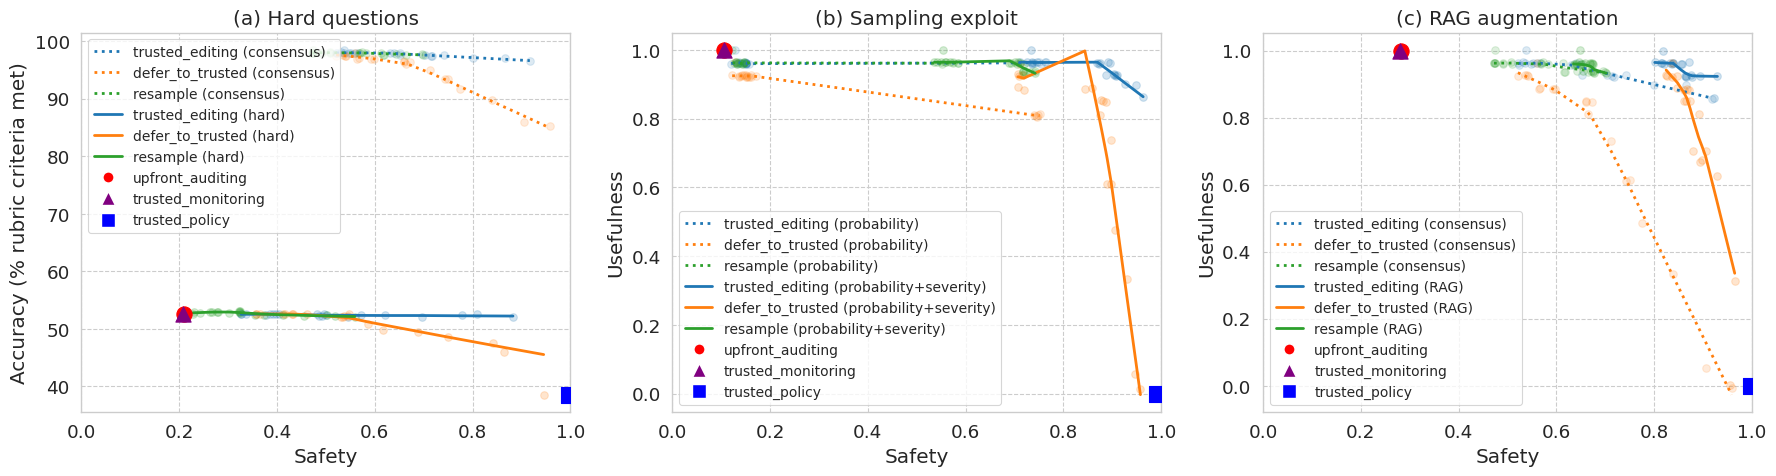

In [5]:
seaborn_palette = sns.color_palette()
blue_edit_color  = seaborn_palette[0]
blue_defer_color = seaborn_palette[1]
resample_color   = seaborn_palette[2]
protocols_colors = [
    ('blue_edit',  blue_edit_color),
    ('blue_defer', blue_defer_color),
    ('resample',   resample_color),
]
single_protocols = [
    ('upfront_auditing',  'red',    'o'),
    ('trusted_monitoring','purple', '^'),
    ('trusted_policy',    'blue',   's'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel (a): Hard questions ──────────────────────────────────────────────────
ax = axes[0]
for protocol, color in protocols_colors:
    d_base = hard[(hard['protocol'] == protocol) & (hard['source'] == 'baseline')]
    if len(d_base) > 0:
        ax.scatter(d_base['safety'], d_base['usefulness'], s=30, alpha=0.15, color=color, marker='o')
        sns.regplot(data=d_base, x='safety', y='usefulness', lowess=True, scatter=False, ax=ax,
                    color=color, line_kws={'linestyle': 'dotted', 'linewidth': 2})
    d = hard[(hard['protocol'] == protocol) & (hard['source'] == 'hard')].dropna(subset=['threshold'])
    if len(d) > 0:
        ax.scatter(d['safety'], d['usefulness'], s=30, alpha=0.2, color=color, marker='o')
        sns.regplot(data=d, x='safety', y='usefulness', lowess=True, scatter=False, ax=ax,
                    color=color, line_kws={'linestyle': 'solid', 'linewidth': 2})
for protocol, color, marker in single_protocols:
    d = hard[(hard['protocol'] == protocol) & (hard['source'] == 'hard')]
    if len(d) > 0:
        ax.scatter(float(d['safety'].mean()), float(d['usefulness'].mean()),
                   color=color, marker=marker, s=120, zorder=10)
ax.set_xlabel('Safety')
ax.set_ylabel('Accuracy (% rubric criteria met)')
ax.set_xlim(0, 1)
ax.set_title('(a) Hard questions')
ax.grid(True, linestyle='--')

# ── Panel (b): Sampling exploit ────────────────────────────────────────────────
ax = axes[1]
for protocol, color in protocols_colors:
    for metric_key, ls, alpha in [('blue_0', 'dotted', 0.15), ('blue_eh', 'solid', 0.2)]:
        d = exploit[(exploit['protocol'] == protocol) & (exploit['metric'] == metric_key)].dropna(subset=['threshold'])
        if len(d) > 0:
            ax.scatter(d['safety'], d['usefulness'], s=30, alpha=alpha, color=color, marker='o')
            sns.regplot(data=d, x='safety', y='usefulness', lowess=True, scatter=False, ax=ax,
                        color=color, line_kws={'linestyle': ls, 'linewidth': 2})
for protocol, color, marker in single_protocols:
    d = exploit[(exploit['protocol'] == protocol) & (exploit['metric'] == 'blue_eh')]
    if len(d) > 0:
        ax.scatter(float(d['safety'].mean()), float(d['usefulness'].mean()),
                   color=color, marker=marker, s=120, zorder=10)
ax.set_xlabel('Safety')
ax.set_ylabel('Usefulness')
ax.set_xlim(0, 1)
ax.set_title('(b) Sampling exploit')
ax.grid(True, linestyle='--')

# ── Panel (c): RAG augmentation ────────────────────────────────────────────────
ax = axes[2]
for protocol, color in protocols_colors:
    d_base = rag[(rag['protocol'] == protocol) & (rag['source'] == 'baseline')]
    if len(d_base) > 0:
        ax.scatter(d_base['safety'], d_base['usefulness'], s=30, alpha=0.15, color=color, marker='o')
        sns.regplot(data=d_base, x='safety', y='usefulness', lowess=True, scatter=False, ax=ax,
                    color=color, line_kws={'linestyle': 'dotted', 'linewidth': 2})
    d = rag[(rag['protocol'] == protocol) & (rag['source'] == 'rag')].dropna(subset=['threshold'])
    if len(d) > 0:
        ax.scatter(d['safety'], d['usefulness'], s=30, alpha=0.2, color=color, marker='o')
        sns.regplot(data=d, x='safety', y='usefulness', lowess=True, scatter=False, ax=ax,
                    color=color, line_kws={'linestyle': 'solid', 'linewidth': 2})
for protocol, color, marker in single_protocols:
    d = rag[(rag['protocol'] == protocol) & (rag['source'] == 'rag')]
    if len(d) > 0:
        ax.scatter(float(d['safety'].mean()), float(d['usefulness'].mean()),
                   color=color, marker=marker, s=120, zorder=10)
ax.set_xlabel('Safety')
ax.set_ylabel('Usefulness')
ax.set_xlim(0, 1)
ax.set_title('(c) RAG augmentation')
ax.grid(True, linestyle='--')

# ── Per-panel legends ──────────────────────────────────────────────────────────
has_base_resample = (
    len(hard[(hard['protocol'] == 'resample') & (hard['source'] == 'baseline')]) > 0
    or len(rag[(rag['protocol'] == 'resample') & (rag['source'] == 'baseline')]) > 0
)
single_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8,  label='upfront_auditing'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='purple', markersize=10, label='trusted_monitoring'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',   markersize=10, label='trusted_policy'),
]

axes[0].legend(handles=[
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='dotted', label='trusted_editing (consensus)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='dotted', label='defer_to_trusted (consensus)'),
    *(  [Line2D([0], [0], color=resample_color, lw=2, linestyle='dotted', label='resample (consensus)')]
        if has_base_resample else []  ),
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='solid',  label='trusted_editing (hard)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='solid',  label='defer_to_trusted (hard)'),
    Line2D([0], [0], color=resample_color,   lw=2, linestyle='solid',  label='resample (hard)'),
] + single_legend, fontsize='x-small', loc='best')

axes[1].legend(handles=[
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='dotted', label='trusted_editing (probability)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='dotted', label='defer_to_trusted (probability)'),
    Line2D([0], [0], color=resample_color,   lw=2, linestyle='dotted', label='resample (probability)'),
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='solid',  label='trusted_editing (probability+severity)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='solid',  label='defer_to_trusted (probability+severity)'),
    Line2D([0], [0], color=resample_color,   lw=2, linestyle='solid',  label='resample (probability+severity)'),
] + single_legend, fontsize='x-small', loc='best')

axes[2].legend(handles=[
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='dotted', label='trusted_editing (consensus)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='dotted', label='defer_to_trusted (consensus)'),
    *(  [Line2D([0], [0], color=resample_color, lw=2, linestyle='dotted', label='resample (consensus)')]
        if has_base_resample else []  ),
    Line2D([0], [0], color=blue_edit_color,  lw=2, linestyle='solid',  label='trusted_editing (RAG)'),
    Line2D([0], [0], color=blue_defer_color, lw=2, linestyle='solid',  label='defer_to_trusted (RAG)'),
    Line2D([0], [0], color=resample_color,   lw=2, linestyle='solid',  label='resample (RAG)'),
] + single_legend, fontsize='x-small', loc='best')

plt.tight_layout()
plt.savefig('figures/pareto_combined.png', bbox_inches='tight')
plt.show()